In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv(r"C:\Users\MOFE\Downloads\insurance.csv")
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
data[['bmi', 'age', 'charges']].corr()

,bmi,age,charges
bmi,1.000000,0.109272,0.198341
age,0.109272,1.000000,0.299008
charges,0.198341,0.299008,1.000000


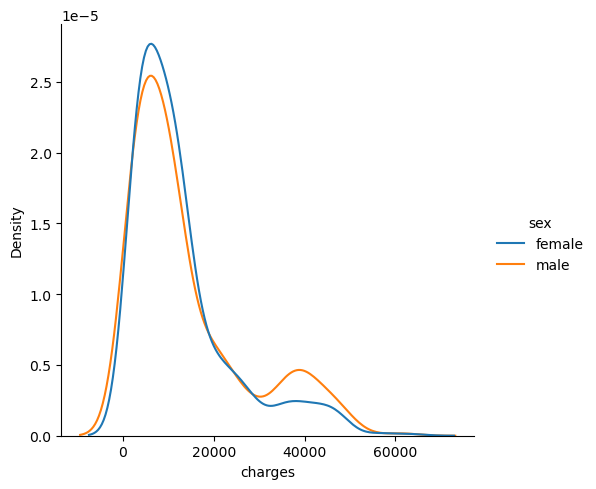

In [7]:
sns.displot(data, x = 'charges', hue = 'sex', kind = 'kde')

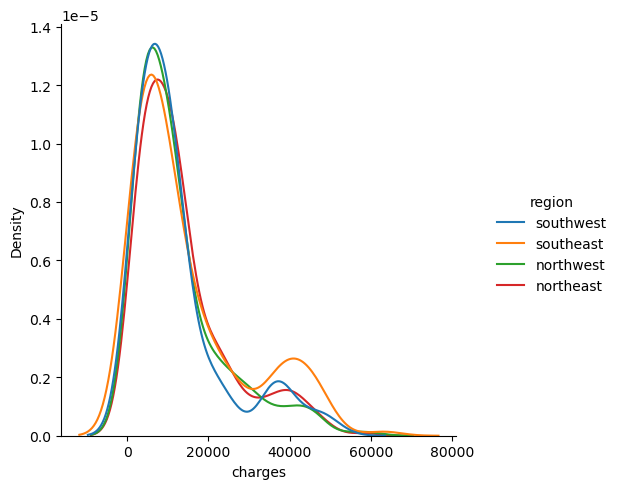

In [9]:
sns.displot(data, x = 'charges', hue = 'region', kind = 'kde')

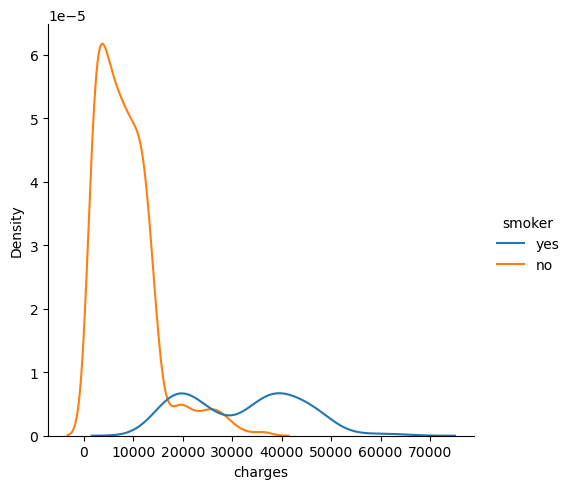

In [11]:
sns.displot(data, x = 'charges', hue = 'smoker', kind = 'kde')

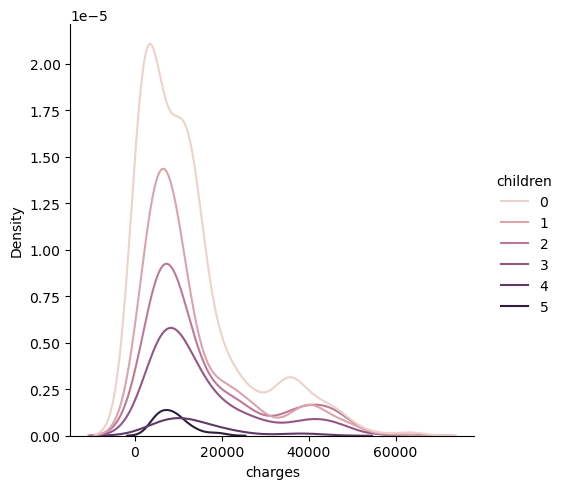

In [13]:
sns.displot(data, x = 'charges', hue = 'children', kind = 'kde')

In [15]:
from sklearn.preprocessing import LabelEncoder

In [21]:
le_smoker = LabelEncoder()
le_gender = LabelEncoder()
le_region = LabelEncoder()

data['smoker'] = le_smoker.fit_transform(data['smoker'])
data['sex'] = le_gender.fit_transform(data['sex'])
data['region'] = le_region.fit_transform(data['region'])

In [23]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


In [25]:
x = data.drop('charges', axis = 1)
x

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1
1334,18,0,31.920,0,0,0
1335,18,0,36.850,0,0,2
1336,21,0,25.800,0,0,3


In [27]:
y = data.charges
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [29]:
from sklearn.model_selection import train_test_split

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size = 0.2,
                                                    random_state = 12)

In [33]:
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [35]:
dtr = DecisionTreeRegressor(random_state = 3)
svr = SVR()
knn = KNeighborsRegressor(n_neighbors = 5, weights = 'distance')

In [37]:
vr = VotingRegressor(estimators = [('tree', dtr),
                                   ('support', svr),
                                   ('neighbors', knn)])

In [39]:
vr.fit(x_train, y_train)

VotingRegressor(estimators=[('tree', DecisionTreeRegressor(random_state=3)),
                            ('support', SVR()),
                            ('neighbors',
                             KNeighborsRegressor(weights='distance'))])

In [41]:
y_pred = vr.predict(x_test)

In [43]:
from sklearn.metrics import r2_score, mean_squared_error

In [45]:
rf = RandomForestRegressor(n_estimators = 20)
rf.fit(x_train, y_train)

RandomForestRegressor(n_estimators=20)

In [47]:
y_pred = rf.predict(x_test)

In [49]:
r2_score(y_test, y_pred)

0.8106187752686262

MODEL SELECTION, HYPER PARAMETER TUNING AND CROSS VALIDATION

In [52]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [54]:
params = {'n_estimators': [10,15,20,25,30,40,50],
         'criterion': ["squared_error", ":absolute_error", "friedman_mse", "poisson"],
         'max_depth': [5,7,9,10,11,12],
         'min_samples_split': [2,3,4],
         'max_features': ["sqrt", "log2"]}

In [56]:
rf = RandomForestRegressor(random_state = 1)

In [58]:
gs = GridSearchCV(estimator = rf, param_grid = params,
                 cv = 5, verbose = 1, n_jobs = -1)

In [60]:
gs.fit(x_train, y_train)

Fitting 5 folds for each of 1008 candidates, totalling 5040 fits


C:\Users\MOFE\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
1260 fits failed out of a total of 5040.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
335 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\MOFE\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\MOFE\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\MOFE\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\MOFE\anaconda3\Lib\site-packages\

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=1), n_jobs=-1,
             param_grid={'criterion': ['squared_error', ':absolute_error',
                                       'friedman_mse', 'poisson'],
                         'max_depth': [5, 7, 9, 10, 11, 12],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [10, 15, 20, 25, 30, 40, 50]},
             verbose=1)

In [62]:
pd.DataFrame(gs.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.153571,0.028992,0.041293,0.027339,squared_error,5,sqrt,2,10,"{'criterion': 'squared_error', 'max_depth': 5,...",0.802390,0.797946,0.852045,0.799094,0.865409,0.823377,0.029208,729
1,0.160013,0.050235,0.024993,0.011049,squared_error,5,sqrt,2,15,"{'criterion': 'squared_error', 'max_depth': 5,...",0.819338,0.814480,0.847925,0.802263,0.862520,0.829305,0.022362,651
2,0.220268,0.073472,0.018897,0.008571,squared_error,5,sqrt,2,20,"{'criterion': 'squared_error', 'max_depth': 5,...",0.825461,0.826652,0.846295,0.810465,0.860180,0.833811,0.017420,581
3,0.311904,0.057630,0.029317,0.008875,squared_error,5,sqrt,2,25,"{'criterion': 'squared_error', 'max_depth': 5,...",0.829527,0.828749,0.850164,0.809084,0.857888,0.835083,0.017288,567
4,0.343809,0.071020,0.019647,0.002827,squared_error,5,sqrt,2,30,"{'criterion': 'squared_error', 'max_depth': 5,...",0.831744,0.833501,0.850163,0.801169,0.855688,0.834453,0.019046,573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,0.257287,0.024076,0.026723,0.014711,poisson,12,log2,4,20,"{'criterion': 'poisson', 'max_depth': 12, 'max...",0.845077,0.847328,0.858133,0.794565,0.868329,0.842686,0.025452,427
1004,0.430646,0.025112,0.014782,0.002505,poisson,12,log2,4,25,"{'criterion': 'poisson', 'max_depth': 12, 'max...",0.849530,0.852572,0.859112,0.802147,0.868881,0.846449,0.023122,195
1005,0.463864,0.035323,0.023130,0.003755,poisson,12,log2,4,30,"{'criterion': 'poisson', 'max_depth': 12, 'max...",0.847171,0.855033,0.856383,0.794607,0.870512,0.844741,0.026172,343
1006,0.632488,0.040459,0.033936,0.010746,poisson,12,log2,4,40,"{'criterion': 'poisson', 'max_depth': 12, 'max...",0.845942,0.856712,0.854036,0.794969,0.865731,0.843478,0.025064,401


In [64]:
gs.best_params_

{'criterion': 'poisson',
 'max_depth': 7,
 'max_features': 'sqrt',
 'min_samples_split': 3,
 'n_estimators': 30}

In [66]:
gs.best_score_

0.8512557139902416

In [68]:
y_pred = gs.predict(x_test)

In [70]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8199507762718983

In [72]:
params = {'n_estimators': [10,15,20,25,30,40,50],
         'criterion': ["squared_error", ":absolute_error", "friedman_mse", "poisson"],
         'max_depth': [5,7,9,10,11,12],
         'min_samples_split': [2,3,4],
         'max_features': ["sqrt", "log2"]}

In [74]:
rs = RandomizedSearchCV(estimator = rf, param_distributions = params,
                 cv = 5, verbose = 1, n_jobs = -1)

In [76]:
rs.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\MOFE\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\MOFE\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\MOFE\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\MOFE\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\MOFE\anaconda3\Lib\site-packages\sklearn

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=1),
                   n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      ':absolute_error',
                                                      'friedman_mse',
                                                      'poisson'],
                                        'max_depth': [5, 7, 9, 10, 11, 12],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_split': [2, 3, 4],
                                        'n_estimators': [10, 15, 20, 25, 30, 40,
                                                         50]},
                   verbose=1)

In [78]:
pd.DataFrame(rs.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_features,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.495365,0.082501,0.041879,0.020497,40,4,sqrt,7,friedman_mse,"{'n_estimators': 40, 'min_samples_split': 4, '...",0.844278,0.862092,0.843579,0.810638,0.872882,0.846694,0.021159,5
1,0.213581,0.018874,0.015907,0.009255,15,3,sqrt,7,poisson,"{'n_estimators': 15, 'min_samples_split': 3, '...",0.834934,0.873301,0.834155,0.820513,0.864970,0.845575,0.020083,6
2,0.678042,0.068231,0.024296,0.005815,40,3,log2,9,poisson,"{'n_estimators': 40, 'min_samples_split': 3, '...",0.842840,0.860753,0.853478,0.807692,0.870652,0.847083,0.021693,3
3,0.645692,0.116894,0.021084,0.007665,50,2,log2,12,squared_error,"{'n_estimators': 50, 'min_samples_split': 2, '...",0.849738,0.859254,0.845735,0.797441,0.861236,0.842681,0.023344,8
4,0.634282,0.113408,0.039952,0.022469,50,2,log2,9,squared_error,"{'n_estimators': 50, 'min_samples_split': 2, '...",0.844765,0.862246,0.852835,0.810079,0.868629,0.847711,0.020494,2
5,0.601065,0.101448,0.033188,0.030043,40,4,log2,12,squared_error,"{'n_estimators': 40, 'min_samples_split': 4, '...",0.848385,0.858475,0.854418,0.794003,0.869120,0.844880,0.026321,7
6,0.728664,0.110876,0.057139,0.049459,30,2,log2,11,friedman_mse,"{'n_estimators': 30, 'min_samples_split': 2, '...",0.858150,0.861877,0.849661,0.803844,0.860986,0.846903,0.021958,4
7,0.433553,0.037553,0.064560,0.026669,20,2,log2,12,friedman_mse,"{'n_estimators': 20, 'min_samples_split': 2, '...",0.838359,0.850921,0.845164,0.799725,0.856640,0.838162,0.020153,9
8,0.005161,0.002494,0.000000,0.000000,30,2,sqrt,7,:absolute_error,"{'n_estimators': 30, 'min_samples_split': 2, '...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
9,0.302136,0.020908,0.019727,0.005516,30,4,sqrt,11,squared_error,"{'n_estimators': 30, 'min_samples_split': 4, '...",0.846960,0.865485,0.859500,0.810118,0.866567,0.849726,0.020995,1


In [80]:
rs.best_params_

{'n_estimators': 30,
 'min_samples_split': 4,
 'max_features': 'sqrt',
 'max_depth': 11,
 'criterion': 'squared_error'}

In [82]:
rs.best_score_

0.8497259462311973

In [84]:
y_pred = rs.predict(x_test)

In [86]:
r2_score(y_test, y_pred)

0.8074369632609235